In [39]:
#Scalar is just single number

a = 5

In [40]:
# Vector is an array of numbers
a = [1, 
     2, 
     3, 
     4, 
     5]

# when it is row vector then a=a^T

In [41]:
# matrix is a 2D array of numbers
A=[[1, 2, 3],
   [4, 5, 6],
   [7, 8, 9]]

print(A[0][0]) # first row, first column

1


In [42]:
# with numpy we can create a matrix and vector and do operations on them
import numpy as np
A=np.array([[1, 2, 3],
            [4, 5, 6],
            [7, 8, 9]], dtype=float)

print(A[:, 0]) # first column
print(A[0, :]) # first row
print(A.diagonal()) # diagonal elements


[1. 4. 7.]
[1. 2. 3.]
[1. 5. 9.]


In [43]:
# tensor is a multi-dimensional array of numbers
T = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
print(T[:, :, 0]) # first elements of matrix in each slice

[[1 3]
 [5 7]]


In [44]:
# transpose of matrix is the mirror image of the matrix along its diagonal

print(A.T) # transpose of matrix

[[1. 4. 7.]
 [2. 5. 8.]
 [3. 6. 9.]]


In [45]:
# add matrices
B = np.array([[9, 8, 7],
              [6, 5, 4],
              [3, 2, 1]])
print(A + B) # add matrices

[[10. 10. 10.]
 [10. 10. 10.]
 [10. 10. 10.]]


In [46]:
# multply or add scalar to matrix
print(A * 2) # multiply matrix by scalar
print(A + 2) # add scalar to matrix

[[ 2.  4.  6.]
 [ 8. 10. 12.]
 [14. 16. 18.]]
[[ 3.  4.  5.]
 [ 6.  7.  8.]
 [ 9. 10. 11.]]


In [47]:
# the implicit copying of b to many locations in memory is called broadcasting. 
print(A + np.array([1, 2, 3])) # add vector to matrix

[[ 2.  4.  6.]
 [ 5.  7.  9.]
 [ 8. 10. 12.]]


In [48]:
# multply matrices, C=AB C_ij = sum(A_ik * B_kj for k in range(n)) where n is the number of columns in A and rows in B
print(A @ B) # multiply matrices

#elementwise multiplication or Hadamard product of matrices
print(A * B) # elementwise multiplication of matrices

[[ 30.  24.  18.]
 [ 84.  69.  54.]
 [138. 114.  90.]]
[[ 9. 16. 21.]
 [24. 25. 24.]
 [21. 16.  9.]]


In [49]:
# multiplication of matrices is distributive over addition, i.e. A(B+C) = AB + AC
C= np.array([[2, 1, 1],
              [1, 4, 1],
              [1, 1, 5]])
print(A @ (B + C) == A @ B + A @ C)

[[ True  True  True]
 [ True  True  True]
 [ True  True  True]]


In [50]:
# multiplication of matrices is associative, i.e. A(BC) = (AB)C
print(A @ (B @ C) == (A @ B) @ C)

[[ True  True  True]
 [ True  True  True]
 [ True  True  True]]


In [51]:
# multiply matrices is not commutative, i.e. AB != BA
print(A @ B == B @ A)

[[False False False]
 [False  True False]
 [False False False]]


In [52]:
# transpose of product of matrices is equal to product of transposes in reverse order, i.e. (AB)^T = B^T A^T
print((A @ B).T==B.T @ A.T) 

# transpose of transpose of matrix is equal to the original matrix, i.e. (A^T)^T = A
print((A.T).T==A)

[[ True  True  True]
 [ True  True  True]
 [ True  True  True]]
[[ True  True  True]
 [ True  True  True]
 [ True  True  True]]


In [53]:
# matrix inverse is a matrix (not singular) that when multiplied with the original matrix gives the identity matrix, i.e. A^-1 A = I
X=np.array([[1, 2], [3, 4]])
X_inv = np.linalg.inv(X)
print(X_inv @ X) # should be identity matrix

[[1.00000000e+00 0.00000000e+00]
 [1.11022302e-16 1.00000000e+00]]


In [58]:
# identity matrix is a square matrix with ones on the diagonal and zeros elsewhere, i.e. I = [[1, 0], [0, 1]]
I = np.eye(3)
print(I) # identity matrix

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [63]:
# rank of a matrix is the number of linearly independent rows or columns in the matrix
print(np.linalg.matrix_rank(A)) # rank of matrix
print(A.shape) # size of matrix

# A matrix is singular as its rank is less than its number of rows or columns. A matrix is non-singular if its rank is equal to its number of rows or columns.

2
(3, 3)


In [67]:
# properties of norm of a vector:
# f(x)=0 => x=0
def norm(x):
    return np.sqrt(np.sum(x**2))

norm(np.array([0, 0, 0])) # should be 0

# triangle inequality: ||x+y|| <= ||x|| + ||y||
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])
print(norm(x + y) <= norm(x) + norm(y)) # should be True

# homogeneity: ||ax|| = |a| ||x||
a = 2
print(norm(a * x) == abs(a) * norm(x)) # should be True 

True
True


In [69]:
# Euclidean norm: ||x|| = sqrt(sum(x_i^2))
def euclidean_norm(x):
    return np.sqrt(np.sum(x**2))

print(euclidean_norm(np.array([0, 0, 0]))) # should be 0
print(euclidean_norm(np.array([1, 2, 3]))) # should be sqrt(14)

# every norm is a convex function, i.e. ||tx + (1-t)y|| <= t||x|| + (1-t)||y|| for 0 <= t <= 1

0.0
3.7416573867739413


In [70]:
# Frobenius norm: ||A||_F = sqrt(sum(A_ij^2))
def frobenius_norm(A):
    return np.sqrt(np.sum(A**2))

frob_norm = frobenius_norm(A)
print(frob_norm) # should be sqrt(285)

16.881943016134134


In [72]:
# dot product of vectors in terms of their Euclidean norms and the cosine of the angle between them, i.e. x.y = ||x|| ||y|| cos(theta)
def dot_product(x, y, phi):
    return euclidean_norm(x) * euclidean_norm(y) * np.cos(phi)

dot_product(np.array([1, 2, 3]), np.array([4, 5, 6]), np.pi/4) 

np.float64(23.2163735324878)

In [83]:
#eigendecomposition of a matrix is the factorization of a matrix into its eigenvalues and eigenvectors, i.e. A = VDV^-1 where D is a diagonal matrix of eigenvalues and V is a matrix of eigenvectors.

X = np.array([[4, -2],
              [1, 1]])

eigenvalues, eigenvectors = np.linalg.eig(X)

D = np.diag(eigenvalues)
V = eigenvectors

print("Eigenvalues:")
print(eigenvalues)

print("Eigenvectors:")
print(V)

print("Diagonal matrix:")
print(D)

print("Reconstructed matrix:")
print(V @ D @ np.linalg.inv(V))

Eigenvalues:
[3. 2.]
Eigenvectors:
[[0.89442719 0.70710678]
 [0.4472136  0.70710678]]
Diagonal matrix:
[[3. 0.]
 [0. 2.]]
Reconstructed matrix:
[[ 4. -2.]
 [ 1.  1.]]


In [89]:
# Singular value decomposition (SVD) is a factorization of a matrix into three matrices, i.e. A = UDV^T where D is a diagonal matrix of singular values, U is a matrix of left singular vectors and V is a matrix of right singular vectors.

S = np.array([[1, 2], [3, 4], [5, 6]])

U, D, Vh = np.linalg.svd(S, full_matrices=False)

D = np.diag(D)

print(U @ D @ Vh)

[[1. 2.]
 [3. 4.]
 [5. 6.]]


In [95]:
# Moore-Penrose pseudoinverse of a matrix is a generalization of the inverse of a matrix that can be applied to non-square matrices or singular matrices. It is defined as A^+ = V D^+ U^T where D^+ is the pseudoinverse of the diagonal matrix D.

S = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

U, D, Vh = np.linalg.svd(S, full_matrices=False)

# Create the pseudoinverse of the diagonal matrix
D_plus = np.zeros((S.shape[1], S.shape[0]))

# Ignore singular values that are effectively zero
tol = np.finfo(float).eps * max(S.shape) * D[0]

for i in range(len(D)):
    if D[i] > tol:
        D_plus[i, i] = 1 / D[i]

# V = Vh.T
S_pseudo_inverse = Vh.T @ D_plus @ U.T

print(S_pseudo_inverse)

S_pinv = np.linalg.pinv(S)

print(np.allclose(S_pseudo_inverse, S_pinv))

[[-6.38888889e-01 -1.66666667e-01  3.05555556e-01]
 [-5.55555556e-02  1.34055206e-16  5.55555556e-02]
 [ 5.27777778e-01  1.66666667e-01 -1.94444444e-01]]
True


In [96]:
# trace of a matrix is the sum of its diagonal elements, i.e. tr(A) = sum(A_ii for i in range(n)) where n is the number of rows or columns in the matrix.
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print(np.trace(A)) # should be 15

15


In [99]:
# Frobenius norm with trace: ||A||_F = sqrt(tr(A^T A))
def frobenius_norm_with_trace(A):
    return np.sqrt(np.trace(A.T @ A))

print(frobenius_norm_with_trace(A)) 

16.881943016134134


Principal direction: [0.65125594 0.75885816]
Encoded values: [-3.6517616  -2.2416475  -0.07267525 -0.18027747  1.98869478  4.15766704]
Reconstructed data:
 [[1.12176858 1.89549758]
 [2.04011376 2.96557417]
 [3.45266981 4.61151646]
 [3.38259323 4.52986164]
 [4.79514928 6.17580393]
 [6.20770534 7.82174622]]
Total reconstruction error: 1.1941032464449914


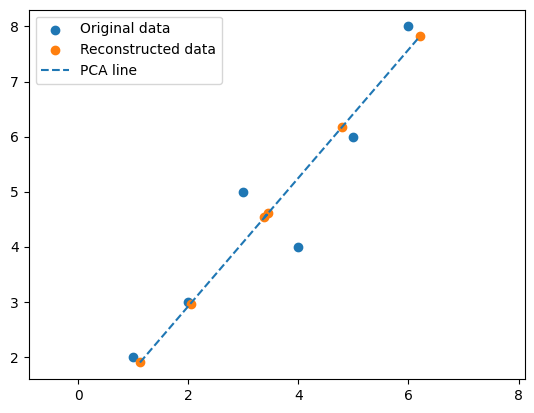

In [100]:
# PCA
import matplotlib.pyplot as plt

# 1. Create data
X = np.array([
    [1, 2],
    [2, 3],
    [3, 5],
    [4, 4],
    [5, 6],
    [6, 8]
])

# 2. Center the data
mean = X.mean(axis=0)
X_centered = X - mean

# 3. Find principal components using SVD
U, s, Vh = np.linalg.svd(X_centered, full_matrices=False)

# First principal direction
w = Vh[0, :]

# 4. Encode: f(x) = c
c = X_centered @ w

# 5. Decode: g(c) = reconstructed x
X_reconstructed = np.outer(c, w) + mean

# 6. Calculate reconstruction error
error = np.sum((X - X_reconstructed) ** 2)

print("Principal direction:", w)
print("Encoded values:", c)
print("Reconstructed data:\n", X_reconstructed)
print("Total reconstruction error:", error)

# 7. Plot original data and reconstructed points
plt.scatter(X[:, 0], X[:, 1], label="Original data")
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1],
            label="Reconstructed data")
plt.plot(X_reconstructed[:, 0], X_reconstructed[:, 1],
         linestyle="--", label="PCA line")
plt.axis("equal")
plt.legend()
plt.show()

PCA error: 1.1941032464449914
Smallest error among tested directions: 1.194707492571369


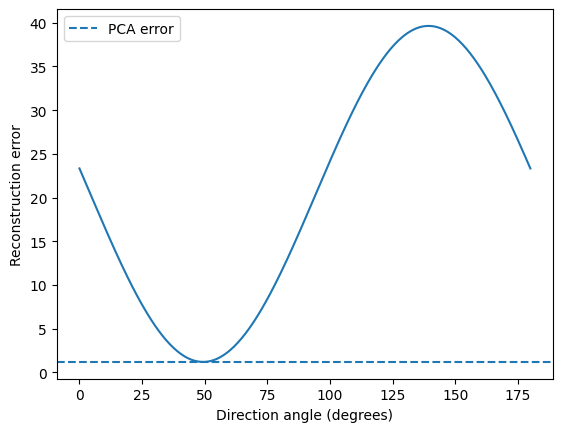

In [102]:
# Try different directions
angles = np.linspace(0, np.pi, 360)
errors = []

for theta in angles:
    direction = np.array([np.cos(theta), np.sin(theta)])

    # Encode
    c_test = X_centered @ direction

    # Decode
    X_test = np.outer(c_test, direction) + mean

    # Reconstruction error
    error_test = np.sum((X - X_test) ** 2)
    errors.append(error_test)

print("PCA error:", error)
print("Smallest error among tested directions:", min(errors))

plt.plot(np.degrees(angles), errors)
plt.axhline(error, linestyle="--", label="PCA error")
plt.xlabel("Direction angle (degrees)")
plt.ylabel("Reconstruction error")
plt.legend()
plt.show()

In [ ]:
# Exercises 
# Matrix operations
A=np.array([[1, 2],
            [3, 4],])

B=np.array([[5, 6], 
            [7, 8]])

